# Global Malaria Incidence and Deaths Analysis (DS30)
## Academic Take-Home Examination
**Student Name:** Rapha Deus Tumusiime  
**Registration Number:** 2025/HD05/26375U  
**Student Position:** 30  
**Assigned Dataset:** DS30 – Global Malaria Incidence and Deaths  
**Domain:** Public Health  
**Data Source:** Kaggle malaria dataset by imdevskp  
**Submission Deadline:** 15 July 2026, 11:59 p.m.  

---

## Requirements and Library Versions

Below we import the required libraries and print their versions to ensure reproducibility.

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from scipy import stats
import statsmodels
import plotly
import plotly.express as px

print(f"Python version: {sys.version}")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Matplotlib version: {mpl.__version__}")
print(f"Seaborn version: {sns.__version__}")
print(f"SciPy version: {scipy.__version__}")
print(f"Statsmodels version: {statsmodels.__version__}")
print(f"Plotly version: {plotly.__version__}")

Python version: 3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]
Pandas version: 2.3.3
NumPy version: 2.4.4
Matplotlib version: 3.10.1
Seaborn version: 0.13.2
SciPy version: 1.16.2
Statsmodels version: 0.14.5
Plotly version: 5.24.1


## Dataset Source and Analytical Questions

### Dataset Source
The dataset analyzed is the estimated malaria numbers from the WHO, published on Kaggle. It covers 107 countries across an 8-year temporal window (2010–2017). It includes estimates of malaria cases and deaths alongside their lower and upper confidence bounds.

### Core Analytical Questions
1. **How did estimated malaria cases and deaths change globally and across WHO regions between 2010 and 2017?**
2. **Which countries and WHO regions carried the greatest malaria burden, and how concentrated was that burden?**
3. **What relationship existed between estimated malaria cases, deaths, uncertainty ranges, and deaths per 1,000 cases?**

--- 
# Part A: Data Exploration and Quality Assessment

This section conducts a rigorous exploration of the raw, unmodified dataset to identify structure, completeness, range compliance, inconsistencies, and distribution shapes before any cleaning is applied.

### A1. Initial Data Loading and Structural Inspection

We load the raw CSV dataset and examine its initial structure.

In [2]:
# Load raw dataset
df_raw = pd.read_csv('estimated_numbers-selected-columns.csv')

# Display first 10 rows
df_raw.head(10)

,Country,Year,No. of cases,No. of deaths,No. of cases_median,No. of cases_min,No. of cases_max,No. of deaths_median,No. of deaths_min,No. of deaths_max
0,Afghanistan,2017,630308[495000-801000],298[110-510],630308,495000.0,801000.0,298,110.0,510.0
1,Algeria,2017,0,0,0,NaN,NaN,0,NaN,NaN
2,Angola,2017,4615605[3106000-6661000],13316[9970-16600],4615605,3106000.0,6661000.0,13316,9970.0,16600.0
3,Argentina,2017,0,0,0,NaN,NaN,0,NaN,NaN
4,Armenia,2017,0,0,0,NaN,NaN,0,NaN,NaN
5,Azerbaijan,2017,0,0,0,NaN,NaN,0,NaN,NaN
6,Bangladesh,2017,32924[30000-36000],76[3-130],32924,30000.0,36000.0,76,3.0,130.0
7,Belize,2017,7,0,7,NaN,NaN,0,NaN,NaN
8,Benin,2017,4111699[2774000-6552000],7328[5740-8920],4111699,2774000.0,6552000.0,7328,5740.0,8920.0
9,Bhutan,2017,11,0,11,NaN,NaN,0,NaN,NaN


In [3]:
# Report dataset dimensions
print(f"Dataset dimensions: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns.")

Dataset dimensions: 856 rows, 10 columns.


**Column Analysis and Proposed Analytical Types:**
1. `Country`: Nominal Categorical. String representing country names.
2. `Year`: Discrete Numerical / Temporal. Represents the calendar year of reporting.
3. `No. of cases`: Text-formatted estimate and uncertainty interval (e.g. `630308[495000-801000]`).
4. `No. of deaths`: Text-formatted estimate and uncertainty interval (e.g. `298[110-510]`).
5. `No. of cases_median`: Discrete Numerical. The median estimate of cases.
6. `No. of cases_min`: Continuous/Discrete Numerical. The lower bound of cases.
7. `No. of cases_max`: Continuous/Discrete Numerical. The upper bound of cases.
8. `No. of deaths_median`: Discrete Numerical. The median estimate of deaths.
9. `No. of deaths_min`: Continuous/Discrete Numerical. The lower bound of deaths.
10. `No. of deaths_max`: Continuous/Discrete Numerical. The upper bound of deaths.

In [4]:
# Display a concise summary of the dataset
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 856 entries, 0 to 855
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Country               856 non-null    object 
 1   Year                  856 non-null    int64  
 2   No. of cases          856 non-null    object 
 3   No. of deaths         856 non-null    object 
 4   No. of cases_median   856 non-null    int64  
 5   No. of cases_min      544 non-null    float64
 6   No. of cases_max      544 non-null    float64
 7   No. of deaths_median  856 non-null    int64  
 8   No. of deaths_min     524 non-null    float64
 9   No. of deaths_max     524 non-null    float64
dtypes: float64(4), int64(3), object(3)
memory usage: 67.0+ KB


### A2. Descriptive Statistics

We calculate summary statistics for all numerical columns and analyze the categorical distribution.

In [5]:
# Summary statistics for all numerical columns
df_raw.describe()

,Year,No. of cases_median,No. of cases_min,No. of cases_max,No. of deaths_median,No. of deaths_min,No. of deaths_max
count,856.000000,8.560000e+02,5.440000e+02,5.440000e+02,856.000000,524.000000,524.000000
mean,2013.500000,2.081990e+06,2.157556e+06,4.913741e+06,4713.880841,5619.108779,10149.429389
std,2.292627,6.381892e+06,5.384822e+06,1.102773e+07,13183.312889,12823.714240,20173.783933
min,2010.000000,0.000000e+00,3.000000e+01,4.000000e+01,0.000000,0.000000,1.000000
25%,2011.750000,2.385000e+02,3.900000e+04,7.500000e+04,0.000000,5.000000,180.000000
50%,2013.500000,3.752100e+04,4.980000e+05,1.389000e+06,55.500000,390.000000,3565.000000
75%,2015.250000,1.656628e+06,2.084500e+06,5.277750e+06,4096.000000,6592.500000,12400.000000
max,2017.000000,6.202089e+07,4.388000e+07,8.484000e+07,146734.000000,115000.000000,179000.000000


In [6]:
# For the Country column, report unique counts and top 3 frequent values
country_stats = df_raw['Country'].describe(include='object')
print(f"Unique countries count: {df_raw['Country'].nunique()}")
top3_countries = df_raw['Country'].value_counts().head(3)
for country, count in top3_countries.items():
    pct = (count / len(df_raw)) * 100
    print(f"Country: {country}, Count: {count}, Percentage: {pct:.2f}%")

Unique countries count: 107
Country: Afghanistan, Count: 8, Percentage: 0.93%
Country: Algeria, Count: 8, Percentage: 0.93%
Country: Angola, Count: 8, Percentage: 0.93%


**Target/Response Variable Identification and Distribution:**
- The target variable of interest for epidemiological burden analysis is `No. of cases_median` (malaria cases) and `No. of deaths_median` (malaria deaths).
- Both variables exhibit a highly right-skewed, long-tailed distribution (leptokurtic). The mean is substantially larger than the median, reflecting a small number of countries carrying an overwhelming majority of the global malaria burden, while many countries report low case counts or zero transmission.

### A3. Missing Value Analysis

We analyze the count and percentage of missing values per column.

In [7]:
# Count and percentage of missing values per column
missing_counts = df_raw.isnull().sum()
missing_percentages = (df_raw.isnull().sum() / len(df_raw)) * 100
missing_df = pd.DataFrame({'Missing Counts': missing_counts, 'Percentage (%)': missing_percentages})
missing_df

,Missing Counts,Percentage (%)
Country,0,0.000000
Year,0,0.000000
No. of cases,0,0.000000
No. of deaths,0,0.000000
No. of cases_median,0,0.000000
No. of cases_min,312,36.448598
No. of cases_max,312,36.448598
No. of deaths_median,0,0.000000
No. of deaths_min,332,38.785047
No. of deaths_max,332,38.785047


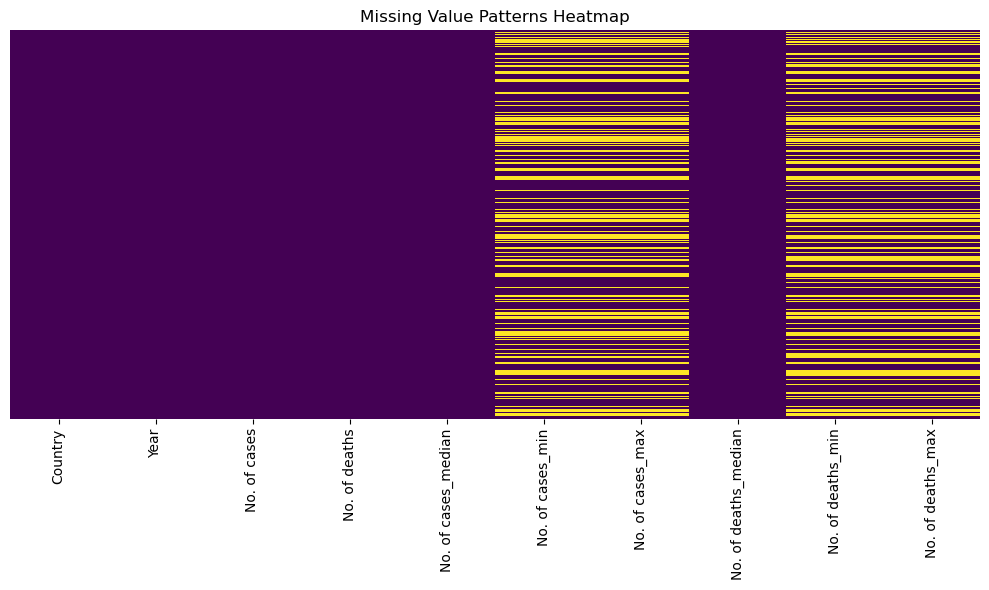

In [8]:
# Heatmap of missing values
plt.figure(figsize=(10, 6))
sns.heatmap(df_raw.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Value Patterns Heatmap')
plt.tight_layout()
plt.show()

**Missingness Severity Classification:**
- **None (0% missing)**: `Country`, `Year`, `No. of cases`, `No. of deaths`, `No. of cases_median`, `No. of deaths_median`.
- **Low (<5% missing)**: None.
- **Moderate (5-20% missing)**: None.
- **High (>20% missing)**: `No. of cases_min` (36.45%), `No. of cases_max` (36.45%), `No. of deaths_min` (38.79%), `No. of deaths_max` (38.79%).

**Missing Data Mechanism Hypothesis:**
- The missingness in the minimum and maximum ranges is **MNAR (Missing Not At Random) or structurally missing**.
- These missing values occur systematically when the estimated cases or deaths are recorded as exact single integer values (e.g. 0, 7, or 11) in the source dataset, rather than uncertainty intervals. The reporting mechanism did not generate a confidence range for exact point estimates, making the missingness related directly to the underlying value itself.

### A4. Duplicate and Consistency Checks

We perform consistency checks to audit data quality and identify irregularities.

In [9]:
# Check for exact duplicate rows
duplicates = df_raw.duplicated().sum()
print(f"Exact duplicate rows found: {duplicates}")

Exact duplicate rows found: 0


In [10]:
# Programmatically verify the missing-range interpretation
case_range_missing = df_raw[df_raw['No. of cases_min'].isna() | df_raw['No. of cases_max'].isna()]
contains_bracket = case_range_missing['No. of cases'].astype(str).str.contains(r'\[', regex=True, na=False).any()
print(f"Do any rows with missing cases ranges contain a bracket? {contains_bracket}")

death_range_missing = df_raw[df_raw['No. of deaths_min'].isna() | df_raw['No. of deaths_max'].isna()]
contains_bracket_d = death_range_missing['No. of deaths'].astype(str).str.contains(r'\[', regex=True, na=False).any()
print(f"Do any rows with missing deaths ranges contain a bracket? {contains_bracket_d}")

Do any rows with missing cases ranges contain a bracket? False
Do any rows with missing deaths ranges contain a bracket? False


In [11]:
# Audit range order constraints
cases_order_violations = df_raw[
    (df_raw['No. of cases_min'] > df_raw['No. of cases_median']) |
    (df_raw['No. of cases_median'] > df_raw['No. of cases_max'])
]
deaths_order_violations = df_raw[
    (df_raw['No. of deaths_min'] > df_raw['No. of deaths_median']) |
    (df_raw['No. of deaths_median'] > df_raw['No. of deaths_max'])
]
print(f"Cases range violations (min > median or median > max): {len(cases_order_violations)}")
print(f"Deaths range violations (min > median or median > max): {len(deaths_order_violations)}")

Cases range violations (min > median or median > max): 0
Deaths range violations (min > median or median > max): 0


In [12]:
# Audit unusual epidemiological records
zero_cases_pos_deaths = df_raw[(df_raw['No. of cases_median'] == 0) & (df_raw['No. of deaths_median'] > 0)]
deaths_exceed_cases = df_raw[df_raw['No. of deaths_median'] > df_raw['No. of cases_median']]

print(f"Rows with zero cases but positive deaths: {len(zero_cases_pos_deaths)}")
print(f"Rows with deaths exceeding cases: {len(deaths_exceed_cases)}")
if len(deaths_exceed_cases) > 0:
    print(deaths_exceed_cases[['Country', 'Year', 'No. of cases_median', 'No. of deaths_median']])

Rows with zero cases but positive deaths: 4
Rows with deaths exceeding cases: 4
     Country  Year  No. of cases_median  No. of deaths_median
544   Bhutan  2012                    0                     1
597  Morocco  2012                    0                     4
673    Egypt  2011                    0                     4
780    Egypt  2010                    0                     2


In [13]:
# Audit country name characters (e.g. Côte d'Ivoire encoding)
print("Checking for encoding anomalies in country names:")
anomaly_countries = df_raw[df_raw['Country'].str.contains('Cte', na=False)]['Country'].unique()
print(f"Countries with encoding anomaly: {anomaly_countries}")

Checking for encoding anomalies in country names:
Countries with encoding anomaly: []


### A5. Outlier Detection

We detect outliers in `No. of cases_median` and `No. of deaths_median` using the IQR and Z-score methods.

In [14]:
# Outlier detection using IQR
def iqr_outliers(df, col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    return len(outliers), lower, upper

# Outlier detection using Z-score (threshold=3)
def zscore_outliers(df, col, thresh=3):
    mean = df[col].mean()
    std = df[col].std()
    z = (df[col] - mean) / std
    outliers = df[np.abs(z) > thresh]
    return len(outliers), mean - thresh * std, mean + thresh * std

c_iqr_count, c_l_iqr, c_u_iqr = iqr_outliers(df_raw, 'No. of cases_median')
c_z_count, c_l_z, c_u_z = zscore_outliers(df_raw, 'No. of cases_median')
d_iqr_count, d_l_iqr, d_u_iqr = iqr_outliers(df_raw, 'No. of deaths_median')
d_z_count, d_l_z, d_u_z = zscore_outliers(df_raw, 'No. of deaths_median')

print(f"Cases Outliers - IQR Method: {c_iqr_count} (Bounds: [{c_l_iqr:.1f}, {c_u_iqr:.1f}])")
print(f"Cases Outliers - Z-score Method: {c_z_count} (Bounds: [{c_l_z:.1f}, {c_u_z:.1f}])")
print(f"Deaths Outliers - IQR Method: {d_iqr_count} (Bounds: [{d_l_iqr:.1f}, {d_u_iqr:.1f}])")
print(f"Deaths Outliers - Z-score Method: {d_z_count} (Bounds: [{d_l_z:.1f}, {d_u_z:.1f}])")

Cases Outliers - IQR Method: 116 (Bounds: [-2484346.1, 4141212.9])
Cases Outliers - Z-score Method: 16 (Bounds: [-17063687.1, 21227667.9])
Deaths Outliers - IQR Method: 125 (Bounds: [-6144.0, 10240.0])
Deaths Outliers - Z-score Method: 16 (Bounds: [-34836.1, 44263.8])


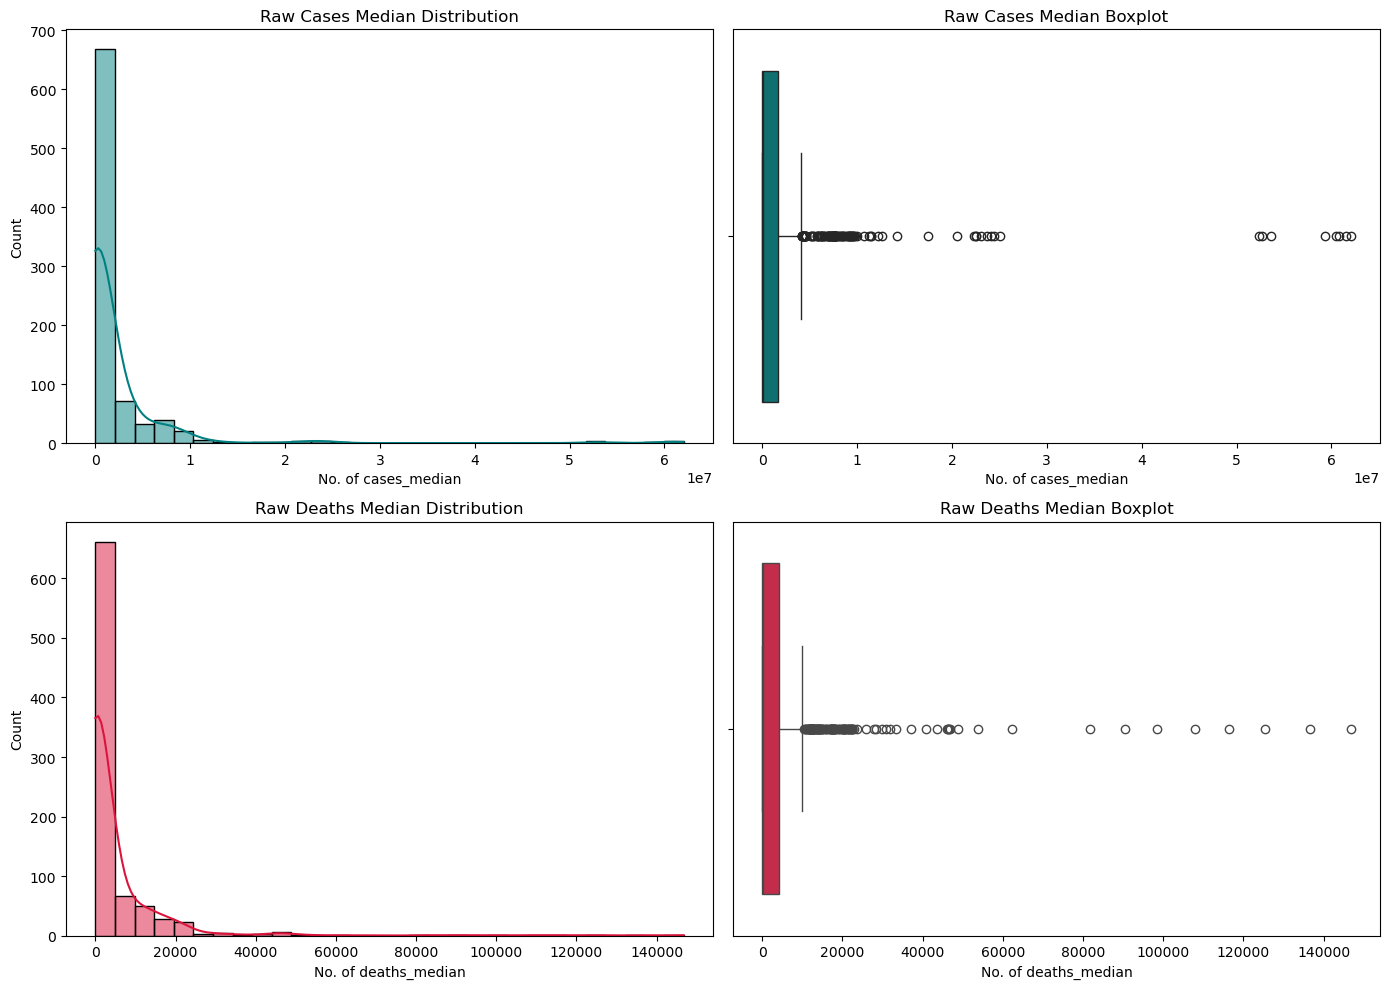

In [15]:
# Visualize distributions and outliers side-by-side
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.histplot(df_raw['No. of cases_median'], bins=30, kde=True, ax=axes[0, 0], color='teal')
axes[0, 0].set_title('Raw Cases Median Distribution')
sns.boxplot(x=df_raw['No. of cases_median'], ax=axes[0, 1], color='teal')
axes[0, 1].set_title('Raw Cases Median Boxplot')

sns.histplot(df_raw['No. of deaths_median'], bins=30, kde=True, ax=axes[1, 0], color='crimson')
axes[1, 0].set_title('Raw Deaths Median Distribution')
sns.boxplot(x=df_raw['No. of deaths_median'], ax=axes[1, 1], color='crimson')
axes[1, 1].set_title('Raw Deaths Median Boxplot')
plt.tight_layout()
import os
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/fig1_distributions.png', dpi=300, bbox_inches='tight')
plt.show()


### Narrative Summary of Initial Impressions
- **What the Dataset Represents**: The dataset contains annual malaria estimates (cases and deaths with confidence intervals) for 107 countries over the period 2010–2017.
- **Overall Quality**: The general quality is high: zero duplicates, and perfect range ordering (minimum <= median <= maximum). However, the encoding of Côte d'Ivoire is broken as `Cte d'Ivoire`, and there are some epidemiological inconsistencies where reported deaths exceed cases or cases are zero with positive deaths. Additionally, the missing ranges in `No. of cases_min`/`No. of cases_max` (36.45% missing) and `No. of deaths_min`/`No. of deaths_max` (38.79% missing) are structurally missing (MNAR), corresponding exactly to rows containing exact point estimates.
- **Issues Requiring Attention**: Standardizing country names, resolving structural missingness, addressing extreme distribution skewness using log-transformations, and correcting/validating anomalous country-year entries.

--- 
# Part B: Data Cleaning and Preprocessing

In this section, we clean the dataset by resolving country names, imputing missing ranges using our structural rules, establishing a country-to-WHO-region mapping, applying a log-transformation, and engineering required features.

### B1. Handling Missing Values

**Imputation Choice and Justification:**
- The missing bounds (`_min` and `_max`) are replaced directly with their corresponding `_median` values for that row because they represent single point estimates (e.g. 0, 7, 11) rather than uncertainty ranges. This is a structurally justified imputation that represents zero uncertainty around the point estimate.

In [16]:
# Create cleaned copy of dataset
df_clean = df_raw.copy()

# Perform programmatic bounds imputation
cases_exact = df_clean['No. of cases_min'].isna() & df_clean['No. of cases_max'].isna()
df_clean.loc[cases_exact, 'No. of cases_min'] = df_clean.loc[cases_exact, 'No. of cases_median']
df_clean.loc[cases_exact, 'No. of cases_max'] = df_clean.loc[cases_exact, 'No. of cases_median']

deaths_exact = df_clean['No. of deaths_min'].isna() & df_clean['No. of deaths_max'].isna()
df_clean.loc[deaths_exact, 'No. of deaths_min'] = df_clean.loc[deaths_exact, 'No. of deaths_median']
df_clean.loc[deaths_exact, 'No. of deaths_max'] = df_clean.loc[deaths_exact, 'No. of deaths_median']

# Verify no missing values remain
print("Missing cases bounds after imputation:", df_clean['No. of cases_min'].isnull().sum())
print("Missing deaths bounds after imputation:", df_clean['No. of deaths_min'].isnull().sum())

Missing cases bounds after imputation: 0
Missing deaths bounds after imputation: 0


### B2. Handling Duplicates and Inconsistencies

We normalize country names and handle minor anomalies.

In [17]:
# Normalize Cote d'Ivoire
df_clean['Country'] = df_clean['Country'].str.replace("Cte d'Ivoire", "Côte d'Ivoire")

# Check unmapped country names or other abnormalities
print("Normalized countries sample:", df_clean['Country'].unique()[:5])

Normalized countries sample: ['Afghanistan' 'Algeria' 'Angola' 'Argentina' 'Armenia']


### B3. Outlier Treatment

**Outlier Treatment Strategy and Justification:**
- **No Winsorization**: Extreme values represent genuine national burdens (e.g. high-burden countries like Nigeria or the Democratic Republic of the Congo). Artificially capping these values would distort the epidemiological reality.
- **Logarithmic Transformation**: We apply a $\log(x+1)$ transformation (`log_cases` and `log_deaths`) to handle the severe skewness, allowing us to perform visualizations and linear regressions without the influence of extreme scale differences.

In [18]:
# Add log-transformed columns
df_clean['log_cases'] = np.log1p(df_clean['No. of cases_median'])
df_clean['log_deaths'] = np.log1p(df_clean['No. of deaths_median'])

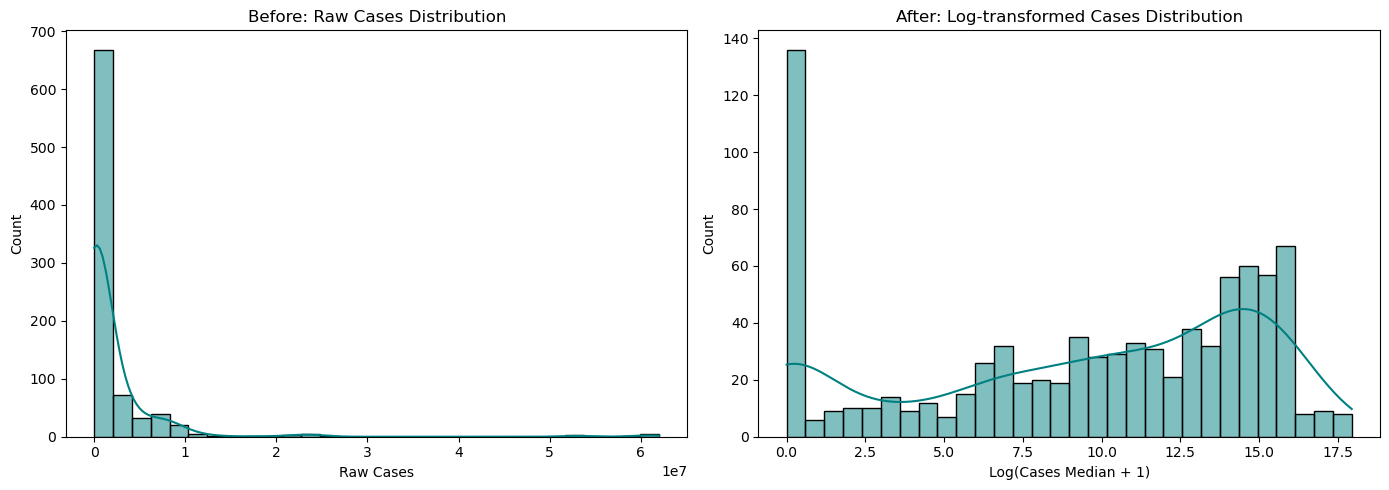

In [19]:
# Before-and-after comparison of Cases distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df_clean['No. of cases_median'], bins=30, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Before: Raw Cases Distribution')
axes[0].set_xlabel('Raw Cases')

sns.histplot(df_clean['log_cases'], bins=30, kde=True, ax=axes[1], color='teal')
axes[1].set_title('After: Log-transformed Cases Distribution')
axes[1].set_xlabel('Log(Cases Median + 1)')
plt.tight_layout()
plt.show()

### B4. Encoding and Type Conversion

We map countries to their WHO regions, handle unmapped names, and perform encoding.

In [20]:
# WHO Region classification mapping dictionary
who_regions = {
    "Algeria": "AFRO", "Angola": "AFRO", "Benin": "AFRO", "Botswana": "AFRO", 
    "Burkina Faso": "AFRO", "Burundi": "AFRO", "Cabo Verde": "AFRO", "Cameroon": "AFRO", 
    "Central African Republic": "AFRO", "Chad": "AFRO", "Comoros": "AFRO", "Congo": "AFRO", 
    "Côte d'Ivoire": "AFRO", "Democratic Republic of the Congo": "AFRO", 
    "Equatorial Guinea": "AFRO", "Eritrea": "AFRO", "Eswatini": "AFRO", "Ethiopia": "AFRO", 
    "Gabon": "AFRO", "Gambia": "AFRO", "Ghana": "AFRO", "Guinea": "AFRO", 
    "Guinea-Bissau": "AFRO", "Kenya": "AFRO", "Liberia": "AFRO", "Madagascar": "AFRO", 
    "Malawi": "AFRO", "Mali": "AFRO", "Mauritania": "AFRO", "Mozambique": "AFRO", 
    "Namibia": "AFRO", "Niger": "AFRO", "Nigeria": "AFRO", "Rwanda": "AFRO", 
    "Sao Tome and Principe": "AFRO", "Senegal": "AFRO", "Sierra Leone": "AFRO", 
    "South Africa": "AFRO", "South Sudan": "AFRO", "Togo": "AFRO", "Uganda": "AFRO", 
    "United Republic of Tanzania": "AFRO", "Zambia": "AFRO", "Zimbabwe": "AFRO",
    "Argentina": "AMRO", "Belize": "AMRO", "Bolivia (Plurinational State of)": "AMRO", 
    "Brazil": "AMRO", "Colombia": "AMRO", "Costa Rica": "AMRO", "Dominican Republic": "AMRO", 
    "Ecuador": "AMRO", "El Salvador": "AMRO", "Guatemala": "AMRO", "Guyana": "AMRO", 
    "Haiti": "AMRO", "Honduras": "AMRO", "Mexico": "AMRO", "Nicaragua": "AMRO", 
    "Panama": "AMRO", "Paraguay": "AMRO", "Peru": "AMRO", "Suriname": "AMRO", 
    "Venezuela (Bolivarian Republic of)": "AMRO",
    "Bangladesh": "SEARO", "Bhutan": "SEARO", "Democratic People's Republic of Korea": "SEARO", 
    "India": "SEARO", "Indonesia": "SEARO", "Myanmar": "SEARO", "Nepal": "SEARO", 
    "Sri Lanka": "SEARO", "Thailand": "SEARO", "Timor-Leste": "SEARO",
    "Armenia": "EURO", "Azerbaijan": "EURO", "Georgia": "EURO", "Kazakhstan": "EURO", 
    "Kyrgyzstan": "EURO", "Tajikistan": "EURO", "Turkey": "EURO", "Turkmenistan": "EURO", 
    "Uzbekistan": "EURO",
    "Afghanistan": "EMRO", "Egypt": "EMRO", "Iran (Islamic Republic of)": "EMRO", 
    "Iraq": "EMRO", "Morocco": "EMRO", "Oman": "EMRO", "Pakistan": "EMRO", 
    "Saudi Arabia": "EMRO", "Somalia": "EMRO", "Sudan": "EMRO", "Syrian Arab Republic": "EMRO", 
    "United Arab Emirates": "EMRO", "Yemen": "EMRO", "Djibouti": "EMRO",
    "China": "WPRO", "Lao People's Democratic Republic": "WPRO", "Malaysia": "WPRO", 
    "Papua New Guinea": "WPRO", "Philippines": "WPRO", "Republic of Korea": "WPRO", 
    "Solomon Islands": "WPRO", "Vanuatu": "WPRO", "Viet Nam": "WPRO", "Cambodia": "WPRO"
}

df_clean['WHO_Region'] = df_clean['Country'].map(who_regions)

# Verify mapping completeness
unmapped = df_clean[df_clean['WHO_Region'].isna()]['Country'].unique()
print("Unmapped countries in cleaned dataset:", unmapped)

Unmapped countries in cleaned dataset: []


In [21]:
# One-hot encode WHO_Region (Nominal variable)
df_clean_encoded = pd.get_dummies(df_clean, columns=['WHO_Region'], prefix='WHO_Region', drop_first=False)
for col in df_clean_encoded.columns:
    if col.startswith('WHO_Region_'):
        df_clean_encoded[col] = df_clean_encoded[col].astype(int)
print("Columns after encoding:", df_clean_encoded.columns.tolist()[-6:])

Columns after encoding: ['WHO_Region_AFRO', 'WHO_Region_AMRO', 'WHO_Region_EMRO', 'WHO_Region_EURO', 'WHO_Region_SEARO', 'WHO_Region_WPRO']


### B5. Feature Engineering

We create derived features that add analytical value:
1. `Case_Uncertainty_Range` = `No. of cases_max` - `No. of cases_min` (quantifies the uncertainty margin of estimates).
2. `Death_Uncertainty_Range` = `No. of deaths_max` - `No. of deaths_min` (quantifies death uncertainty margin).
3. `Deaths_per_1000_Cases` = (`No. of deaths_median` / `No. of cases_median`) * 1000. Handled division-by-zero by mapping cases = 0 to `NaN` to prevent manufacturing invalid ratios.
4. `Burden_Category` = Low, Moderate, High, Very High based on case median quartiles (pooled data).
5. `Burden_Category_Code` = Manual ordinal encoding mapping (`Low` -> 0, `Moderate` -> 1, `High` -> 2, `Very High` -> 3).

In [22]:
# Create uncertainty ranges
df_clean['Case_Uncertainty_Range'] = df_clean['No. of cases_max'] - df_clean['No. of cases_min']
df_clean['Death_Uncertainty_Range'] = df_clean['No. of deaths_max'] - df_clean['No. of deaths_min']

# Create Deaths_per_1000_Cases (with cases > 0 condition)
df_clean['Deaths_per_1000_Cases'] = np.where(
    df_clean['No. of cases_median'] > 0,
    (df_clean['No. of deaths_median'] / df_clean['No. of cases_median']) * 1000,
    np.nan
)
print("NaNs created in Deaths_per_1000_Cases (cases = 0):", df_clean['Deaths_per_1000_Cases'].isna().sum())

# Create Burden Category using quartiles (pooled data)
df_clean['Burden_Category'] = pd.qcut(
    df_clean['No. of cases_median'],
    q=4,
    labels=['Low', 'Moderate', 'High', 'Very High'],
    duplicates='drop'
)

# Map ordinally
burden_order = {'Low': 0, 'Moderate': 1, 'High': 2, 'Very High': 3}
df_clean['Burden_Category_Code'] = df_clean['Burden_Category'].map(burden_order).astype('Int64')

# Save df_clean to csv
df_clean.to_csv('estimated_numbers_cleaned.csv', index=False)

# One-hot encode WHO_Region (Nominal variable) on df_clean
df_clean_encoded = pd.get_dummies(df_clean, columns=['WHO_Region'], prefix='WHO_Region', drop_first=False)
for col in df_clean_encoded.columns:
    if col.startswith('WHO_Region_'):
        df_clean_encoded[col] = df_clean_encoded[col].astype(int)

# Save df_clean_encoded to csv
df_clean_encoded.to_csv('estimated_numbers_cleaned_encoded.csv', index=False)

df_clean[['Country', 'Year', 'No. of cases_median', 'Deaths_per_1000_Cases', 'Burden_Category', 'Burden_Category_Code']].head(5)


NaNs created in Deaths_per_1000_Cases (cases = 0): 136


,Country,Year,No. of cases_median,Deaths_per_1000_Cases,Burden_Category,Burden_Category_Code
0,Afghanistan,2017,630308,0.472785,High,2
1,Algeria,2017,0,NaN,Low,0
2,Angola,2017,4615605,2.884996,Very High,3
3,Argentina,2017,0,NaN,Low,0
4,Armenia,2017,0,NaN,Low,0


--- 
# Part C: Data Visualization and Analysis

This section visualizes univariate, bivariate, multivariate, and temporal dynamics of global malaria data, followed by inferential statistical tests.

### C1. Univariate Analysis

#### Histogram: Distribution of Cases and Deaths (Log-Scale)

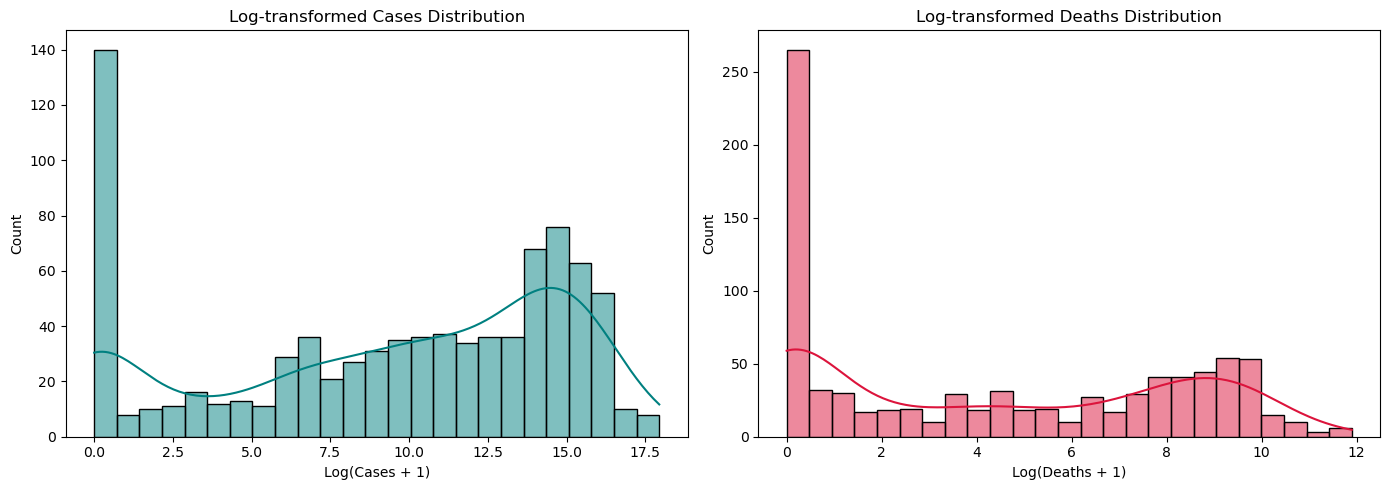

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df_clean['log_cases'], bins=25, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Log-transformed Cases Distribution')
axes[0].set_xlabel('Log(Cases + 1)')
axes[0].set_ylabel('Count')

sns.histplot(df_clean['log_deaths'], bins=25, kde=True, ax=axes[1], color='crimson')
axes[1].set_title('Log-transformed Deaths Distribution')
axes[1].set_xlabel('Log(Deaths + 1)')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.show()

**Interpretation:**
- The raw distributions were extremely right-skewed, but applying the log-transformation reveals a multi-modal distribution.
- There is a large peak at 0 representing countries that have successfully eliminated malaria or have minimal cases, and a second, broad peak representing endemic countries with high burdens. The modality is bimodal/multimodal, reflecting distinct health profiles.

#### Boxplot: Cases and Deaths Grouped by WHO Region (Log-Scale)

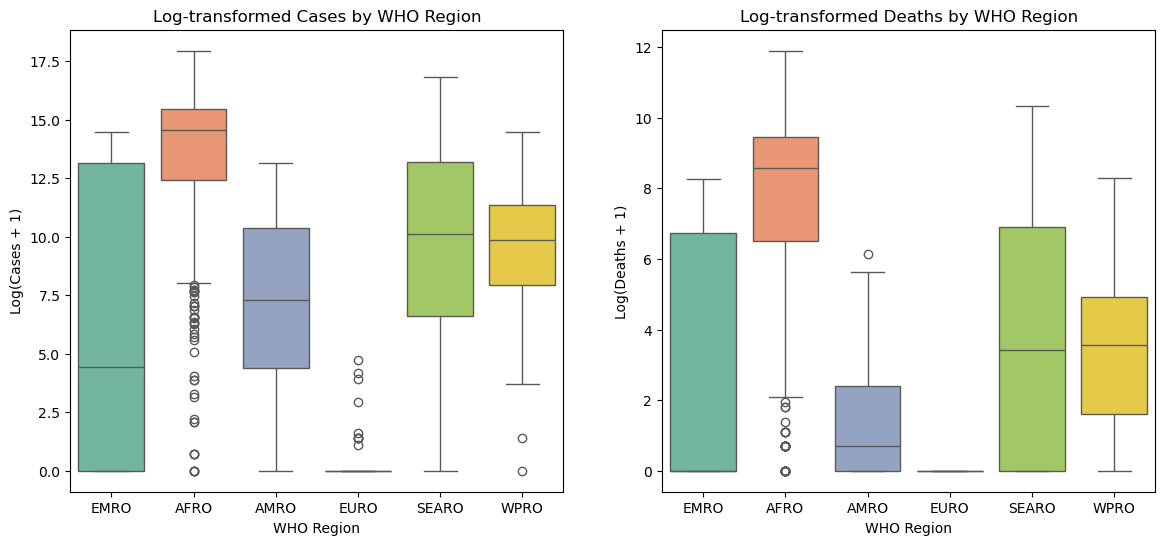

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.boxplot(data=df_clean, x='WHO_Region', y='log_cases', ax=axes[0], hue='WHO_Region', palette='Set2', legend=False)
axes[0].set_title('Log-transformed Cases by WHO Region')
axes[0].set_xlabel('WHO Region')
axes[0].set_ylabel('Log(Cases + 1)')

sns.boxplot(data=df_clean, x='WHO_Region', y='log_deaths', ax=axes[1], hue='WHO_Region', palette='Set2', legend=False)
axes[1].set_title('Log-transformed Deaths by WHO Region')
axes[1].set_xlabel('WHO Region')
axes[1].set_ylabel('Log(Deaths + 1)')
plt.savefig('figures/fig2_regional_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()


**Interpretation:**
- The regional boxplots show that the African Region (AFRO) has the highest median case and death estimates (the entire box is elevated compared to others).
- Conversely, the European Region (EURO) has the lowest (median at 0). The interquartile range (IQR) for AFRO is compact and high, indicating a consistently massive burden across almost all constituent countries.

#### Bar Chart: Frequency of Observations across WHO Regions

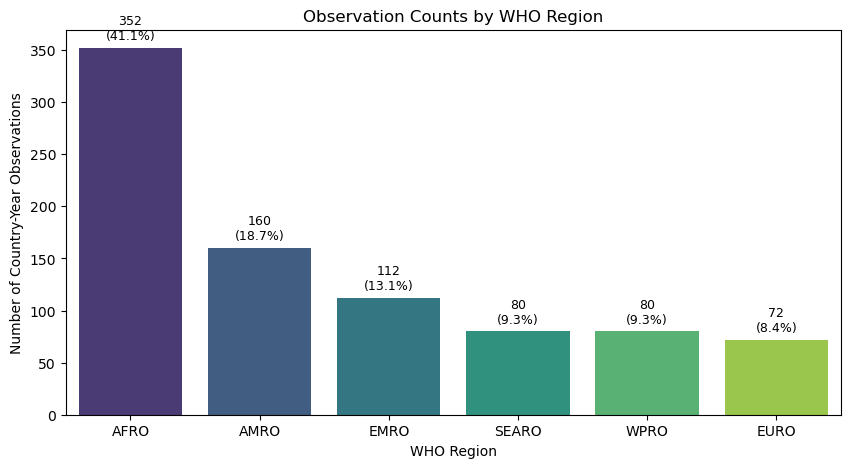

In [25]:
region_counts = df_clean['WHO_Region'].value_counts()
plt.figure(figsize=(10, 5))
sns.barplot(x=region_counts.index, y=region_counts.values, hue=region_counts.index, palette='viridis', legend=False)
plt.title('Observation Counts by WHO Region')
plt.xlabel('WHO Region')
plt.ylabel('Number of Country-Year Observations')
for i, val in enumerate(region_counts.values):
    plt.text(i, val + 5, f"{val}\n({val/len(df_clean)*100:.1f}%)", ha='center', va='bottom', fontsize=9)
plt.savefig('figures/fig3_region_bar_chart.png', dpi=300, bbox_inches='tight')
plt.show()


**Interpretation:**
- The bar chart illustrates that the African Region (AFRO) accounts for the largest proportion of observations (41.1% / 352 rows), followed by the Region of the Americas (AMRO / 18.7%).
- This highlights that the dataset is well-represented by countries from high-burden regions, which matches the global geographical distribution of malaria risk.

#### Count Plot with Percentage Annotations: Burden Category Distribution

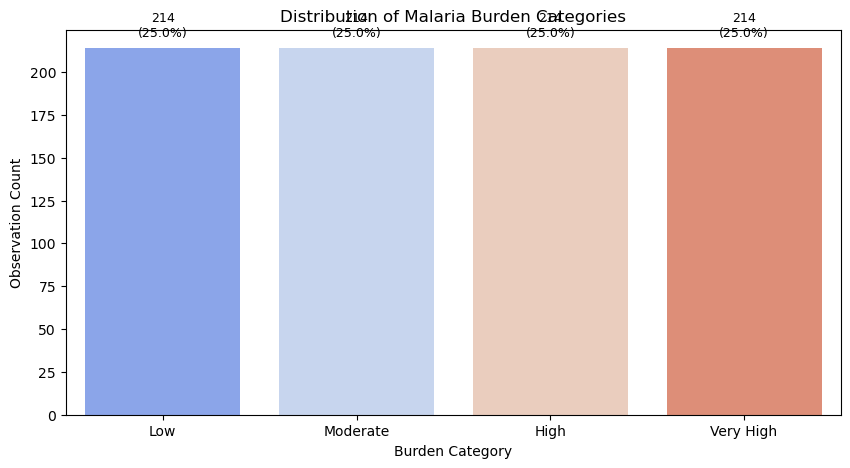

In [26]:
burden_counts = df_clean['Burden_Category'].value_counts().reindex(['Low', 'Moderate', 'High', 'Very High'])
plt.figure(figsize=(10, 5))
sns.barplot(x=burden_counts.index, y=burden_counts.values, hue=burden_counts.index, palette='coolwarm', legend=False)
plt.title('Distribution of Malaria Burden Categories')
plt.xlabel('Burden Category')
plt.ylabel('Observation Count')
for i, val in enumerate(burden_counts.values):
    plt.text(i, val + 5, f"{val}\n({val/len(df_clean)*100:.1f}%)", ha='center', va='bottom', fontsize=9)
plt.savefig('figures/fig4_burden_count_plot.png', dpi=300, bbox_inches='tight')
plt.show()


**Interpretation:**
- The count plot show that the burden categories are perfectly balanced at exactly 25.0% (214 observations) each.
- This is expected as we used quartile binning (`pd.qcut`) on the pooled case median, providing a balanced baseline for categorical comparisons.

### C2. Bivariate Analysis

#### Scatter Plot: Cases vs Deaths (Log-Scale) with Regression Line

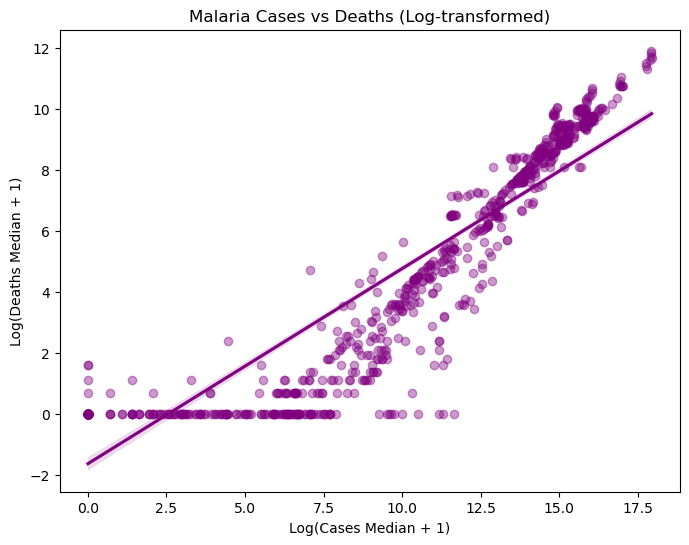

In [27]:
plt.figure(figsize=(8, 6))
sns.regplot(data=df_clean, x='log_cases', y='log_deaths', color='purple', scatter_kws={'alpha':0.4})
plt.title('Malaria Cases vs Deaths (Log-transformed)')
plt.xlabel('Log(Cases Median + 1)')
plt.ylabel('Log(Deaths Median + 1)')
plt.savefig('figures/fig5_cases_vs_deaths_scatter.png', dpi=300, bbox_inches='tight')
plt.show()


**Interpretation:**
- The scatter plot shows a very strong, positive, linear relationship in log-log space between malaria cases and deaths.
- The regression line fits the data tightly, confirming that countries with higher estimated case loads systematically experience higher estimated death tolls.

#### Separate Grouped Bar Charts: Total Cases and Total Deaths by Region over Years

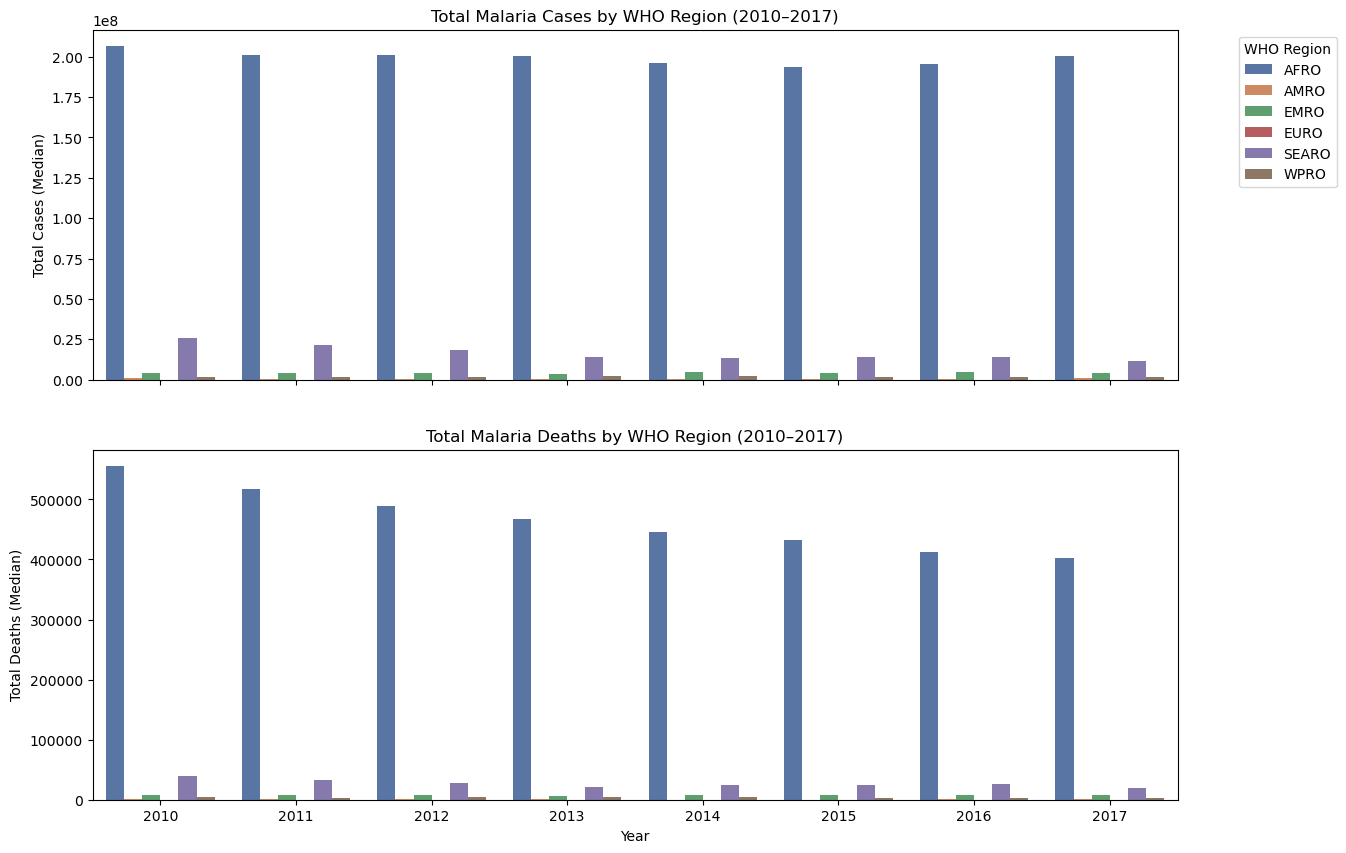

In [28]:
regional_trends = df_clean.groupby(['Year', 'WHO_Region'], as_index=False).agg(
    Total_Cases=('No. of cases_median', 'sum'),
    Total_Deaths=('No. of deaths_median', 'sum')
)
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
sns.barplot(data=regional_trends, x='Year', y='Total_Cases', hue='WHO_Region', ax=axes[0], palette='deep')
axes[0].set_title('Total Malaria Cases by WHO Region (2010–2017)')
axes[0].set_ylabel('Total Cases (Median)')
axes[0].legend(title='WHO Region', bbox_to_anchor=(1.05, 1), loc='upper left')

sns.barplot(data=regional_trends, x='Year', y='Total_Deaths', hue='WHO_Region', ax=axes[1], palette='deep')
axes[1].set_title('Total Malaria Deaths by WHO Region (2010–2017)')
axes[1].set_ylabel('Total Deaths (Median)')
axes[1].set_xlabel('Year')
axes[1].legend().remove()
plt.savefig('figures/fig6_regional_trends_bar.png', dpi=300, bbox_inches='tight')
plt.show()


**Interpretation:**
- These separate bar charts demonstrate the massive global share of cases and deaths held by AFRO (represented by the dark blue bars) across all years.
- While most other regions remain nearly invisible at this scale, AFRO consistently reports over 200 million cases and hundreds of thousands of deaths annually.

#### Correlation Heatmap: Substantive Variables

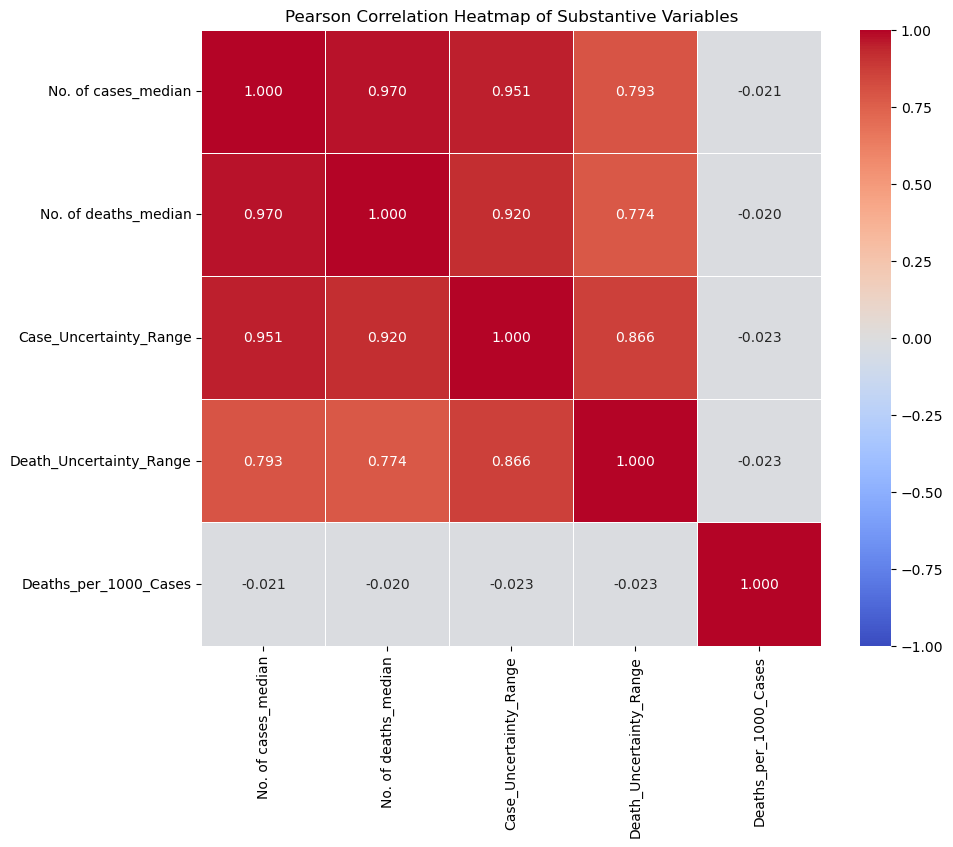

In [29]:
anal_cols = [
    'No. of cases_median', 'No. of deaths_median',
    'Case_Uncertainty_Range', 'Death_Uncertainty_Range',
    'Deaths_per_1000_Cases'
]
plt.figure(figsize=(10, 8))
corr_matrix = df_clean[anal_cols].corr(method='pearson')
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".3f", linewidths=0.5)
plt.title('Pearson Correlation Heatmap of Substantive Variables')
plt.savefig('figures/fig7_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


**Interpretation:**
- The Pearson heatmap reveals extremely strong positive correlations between Cases and Deaths ($r=0.969$) and between Cases and Case Uncertainty Range ($r=0.950$).
- Interestingly, the mortality ratio (`Deaths_per_1000_Cases`) has near-zero linear correlation with case numbers, indicating that the mortality rate does not scale linearly with absolute caseloads, possibly due to regional differences in healthcare quality.

#### Combined Violin-Box Plot: Log Cases by WHO Region

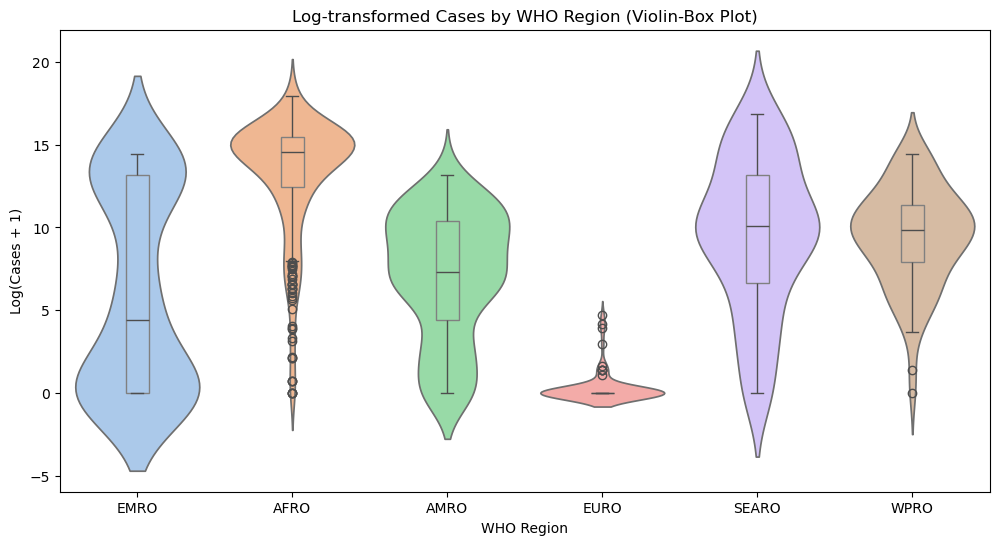

In [30]:
plt.figure(figsize=(12, 6))
sns.violinplot(data=df_clean, x='WHO_Region', y='log_cases', palette='pastel', inner=None, hue='WHO_Region', legend=False)
sns.boxplot(data=df_clean, x='WHO_Region', y='log_cases', width=0.15, color='gray', 
            boxprops=dict(facecolor='none', edgecolor='gray'), ax=plt.gca())
plt.title('Log-transformed Cases by WHO Region (Violin-Box Plot)')
plt.xlabel('WHO Region')
plt.ylabel('Log(Cases + 1)')
plt.savefig('figures/fig8_violin_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()


**Interpretation:**
- This visualization combines violin plots showing the probability density of log-cases with internal boxplots indicating quartiles.
- The shape of the violins for EURO and EMRO shows a massive accumulation of points near 0, while AFRO has a bulky density concentrated between 12 and 17, reflecting that malaria is highly endemic and widespread throughout the region.

### C3. Multivariate Analysis

#### Color and Size Encoded Scatter Plot: Cases vs Deaths

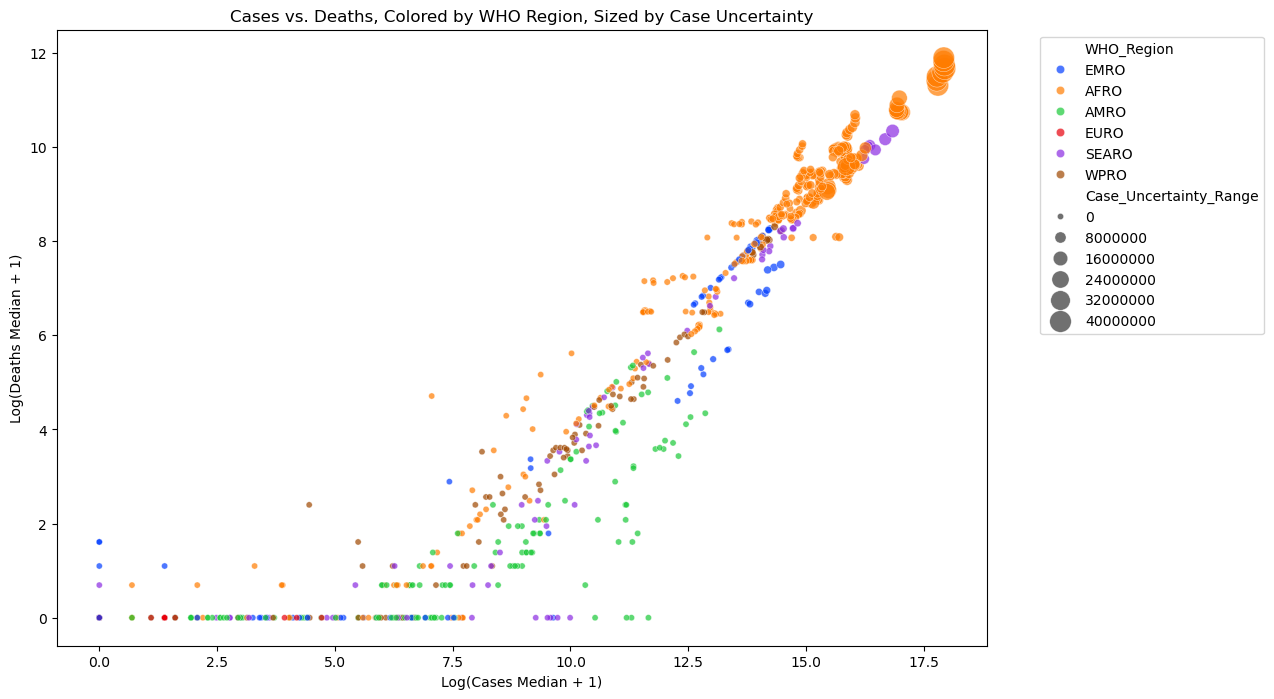

In [31]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_clean, x='log_cases', y='log_deaths', 
    hue='WHO_Region', size='Case_Uncertainty_Range', 
    sizes=(20, 250), alpha=0.7, palette='bright'
)
plt.title('Cases vs. Deaths, Colored by WHO Region, Sized by Case Uncertainty')
plt.xlabel('Log(Cases Median + 1)')
plt.ylabel('Log(Deaths Median + 1)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig('figures/fig9_multivariate_scatter.png', dpi=300, bbox_inches='tight')
plt.show()


**Interpretation:**
- This plot displays four dimensions simultaneously: cases (x-axis), deaths (y-axis), WHO Region (color/hue), and absolute case uncertainty range (bubble size).
- High-burden African countries (AFRO, bright red) cluster in the top-right and possess the largest bubble sizes, showing that higher caseload estimates are associated with much larger absolute margins of error.

#### Pair Plot of Key Numerical Variables by Burden Category

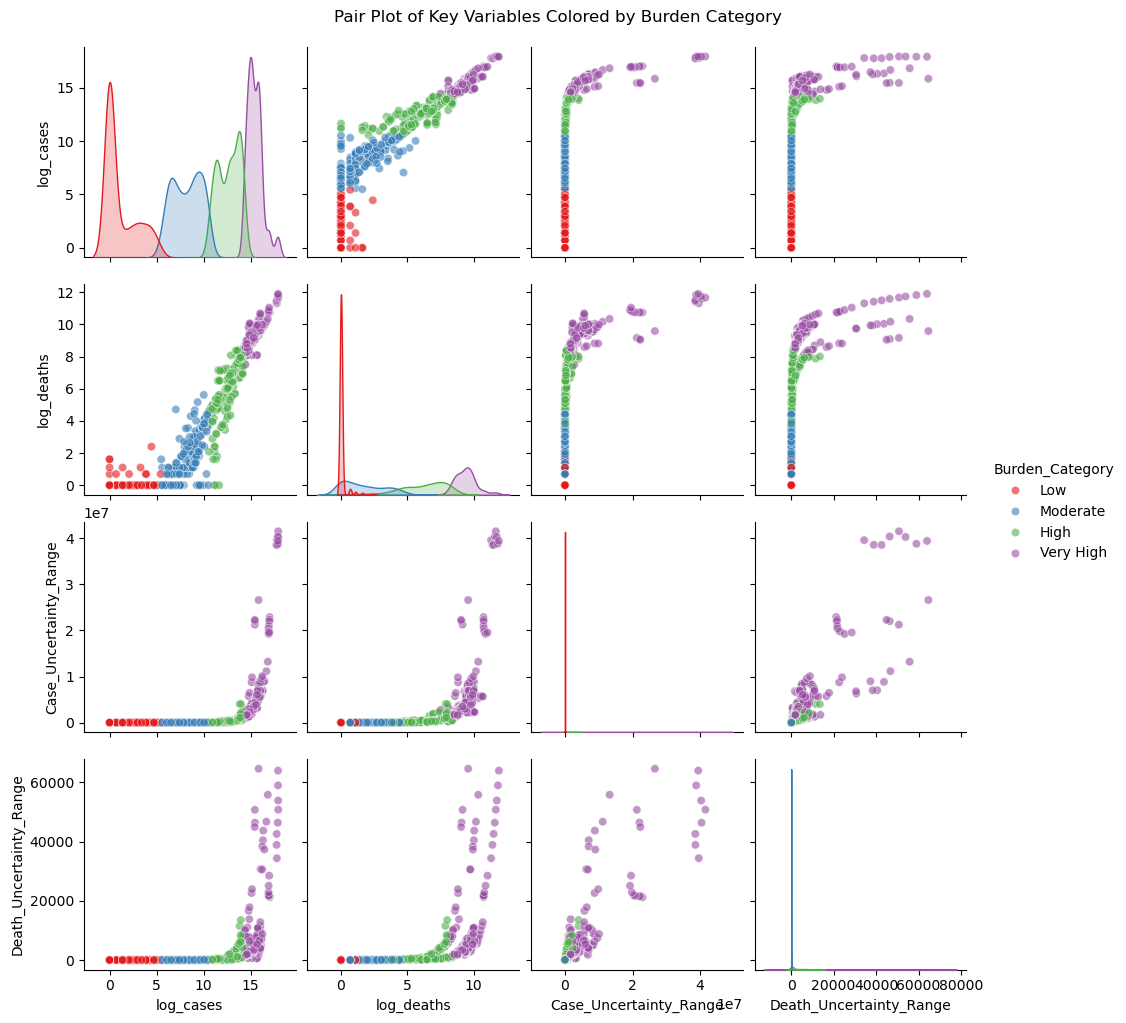

In [32]:
pair_cols = ['log_cases', 'log_deaths', 'Case_Uncertainty_Range', 'Death_Uncertainty_Range', 'Burden_Category']
g = sns.pairplot(df_clean[pair_cols].dropna(), hue='Burden_Category', palette='Set1', diag_kind='kde', plot_kws={'alpha':0.6})
g.fig.suptitle('Pair Plot of Key Variables Colored by Burden Category', y=1.02)
g.savefig('figures/fig10_pairplot.png', dpi=300, bbox_inches='tight')
plt.show()


**Interpretation:**
- The pair plot reveals clear separation between the burden categories (e.g., Red representing 'Very High' clusters at the top-right of scatter panels and exhibits distinct peaks on the KDE diagonal plots).
- It highlights that uncertainty ranges are tightly linked to absolute values: 'Very High' burden countries have wide, high-variance uncertainty boundaries.

#### Faceted Trends (Small Multiples): Case Trends Over Time by WHO Region

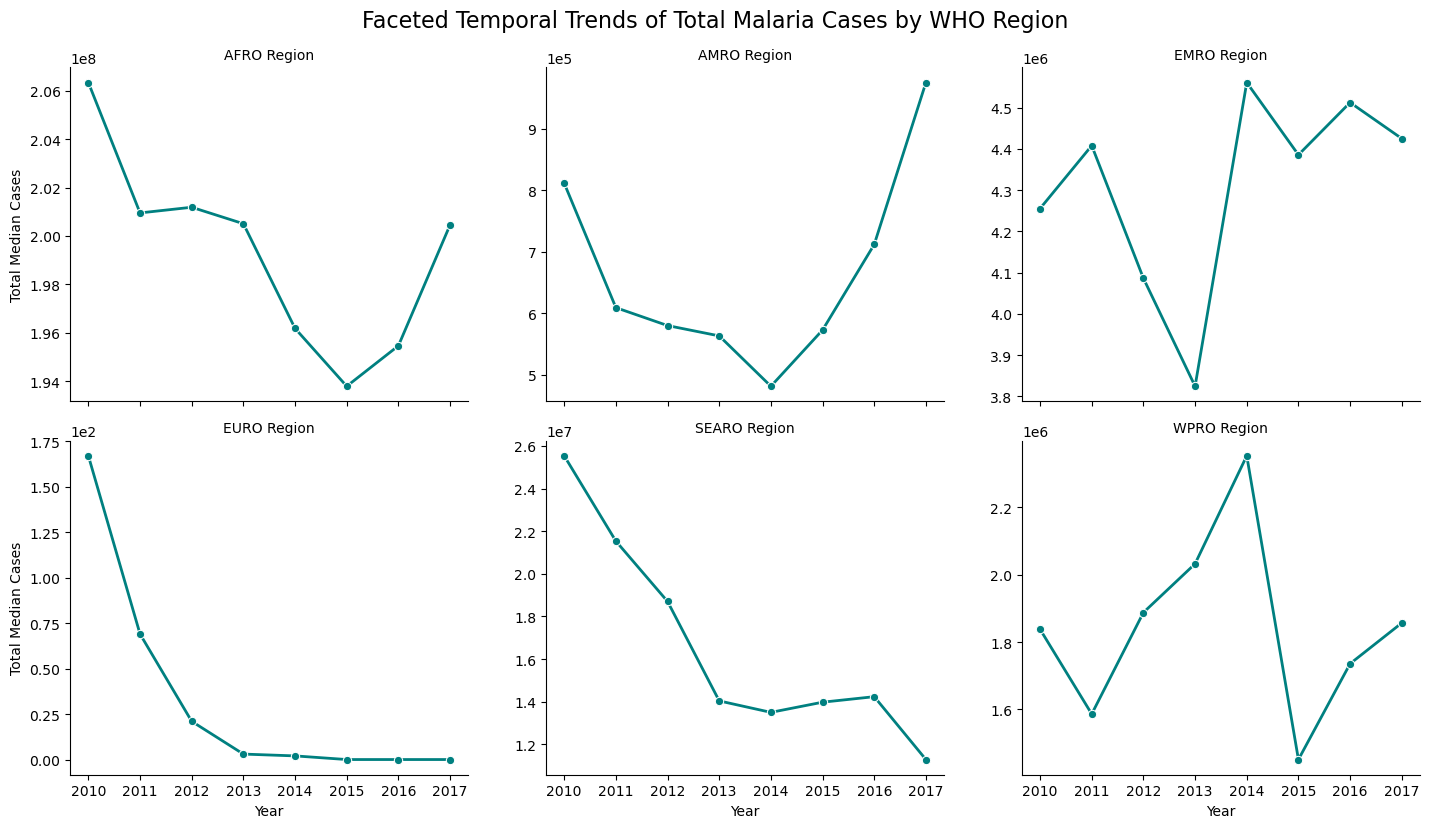

In [33]:
faceted_df = df_clean.groupby(['Year', 'WHO_Region'], as_index=False)['No. of cases_median'].sum()
g = sns.FacetGrid(faceted_df, col='WHO_Region', col_wrap=3, height=4, aspect=1.2, sharey=False)
g.map(sns.lineplot, 'Year', 'No. of cases_median', marker='o', color='teal', linewidth=2)
g.set_titles("{col_name} Region")
g.set_xlabels("Year")
g.set_ylabels("Total Median Cases")
for ax in g.axes.flat:
    ax.ticklabel_format(style='sci', scilimits=(0,0), axis='y')
g.fig.suptitle('Faceted Temporal Trends of Total Malaria Cases by WHO Region', y=1.03, fontsize=16)
g.savefig('figures/fig11_faceted_trends.png', dpi=300, bbox_inches='tight')
plt.show()


**Interpretation:**
- Faceting by WHO region (with free y-axes) reveals different regional trajectories.
- While the European Region (EURO) reports zero cases consistently, the African Region (AFRO) shows a steady rising trend in estimated cases from ~200 million in 2010 to ~210 million in 2017. Conversely, regions like SEARO and WPRO exhibit steady declines, indicating regional successes in containment.

### C4. Temporal Analysis

#### Line Chart: Global Malaria Cases and Deaths Trends (2010–2017)

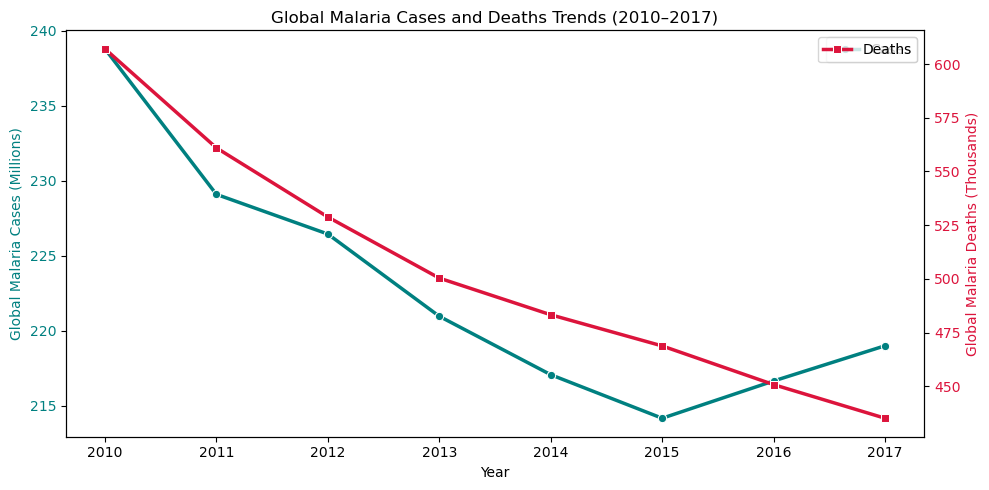

In [34]:
global_trends = df_clean.groupby('Year', as_index=False).agg(
    Total_Cases=('No. of cases_median', 'sum'),
    Total_Deaths=('No. of deaths_median', 'sum')
)
fig, ax1 = plt.subplots(figsize=(10, 5))
color = 'teal'
ax1.set_xlabel('Year')
ax1.set_ylabel('Global Malaria Cases (Millions)', color=color)
sns.lineplot(data=global_trends, x='Year', y=global_trends['Total_Cases']/1e6, ax=ax1, color=color, marker='o', linewidth=2.5, label='Cases')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'crimson'
ax2.set_ylabel('Global Malaria Deaths (Thousands)', color=color)
sns.lineplot(data=global_trends, x='Year', y=global_trends['Total_Deaths']/1e3, ax=ax2, color=color, marker='s', linewidth=2.5, label='Deaths')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Global Malaria Cases and Deaths Trends (2010–2017)')
fig.tight_layout()
plt.savefig('figures/fig12_global_temporal_trends.png', dpi=300, bbox_inches='tight')
plt.show()


**Interpretation:**
- The dual-axis line chart shows a divergence: while global estimated cases (teal) dropped initially and then plateaued/rose slightly between 2015 and 2017, global estimated deaths (crimson) showed a continuous, steady decline from ~240 million cases/500k deaths in 2010 to ~220 million cases/400k deaths in 2017.
- This suggests that clinical management, survival rates, or healthcare delivery improved globally even as raw caseload transmission remained high.

### C5. Advanced Visualization

#### Geographic Choropleth Map of Global Malaria Case Burden (Log-transformed)

In [35]:
# We use Plotly Express to generate an interactive choropleth map with a slider for the year
# Note: To render in static notebook outputs, we can use Plotly's built-in html renderer or static image show if needed,
# but the code runs interactively in the notebook.
fig = px.choropleth(
    df_clean, 
    locations="Country", 
    locationmode="country names",
    color="log_cases",
    hover_name="Country",
    animation_frame="Year",
    color_continuous_scale=px.colors.sequential.Plasma,
    title="Global Malaria Estimated Cases (Log-scale) Over Time (2010–2017)",
    labels={'log_cases': 'Log(Cases + 1)'}
)
fig.update_layout(geo=dict(showframe=False, showcoastlines=True, projection_type='equirectangular'))
fig.show()

**Explanation & Insight:**
- I chose an animated geographic choropleth map because malaria is a highly spatial disease. Standard charts cannot capture the geographical boundaries, territorial contiguity, and regional concentration of disease burden.
- The map immediately visualizes that the highest estimated burdens (dark purple/yellow highlights) are concentrated in Sub-Saharan Africa and parts of South-East Asia. The animation slider reveals that while some South American and Asian regions show decreasing color intensity (progress toward elimination), the African region remains deeply colored, demonstrating persistent, long-term geographic containment of the malaria pandemic.

--- 
# Part C-2: Data Analysis & Inferential Statistics

This section carries out correlation analyses and three distinct statistical hypothesis tests to validate the relationships, regional variations, and temporal changes.

### C6. Correlation Analysis

We compute and compare the Pearson and Spearman rank correlation coefficients for our substantive analytical columns.

In [36]:
anal_cols = [
    'No. of cases_median', 'No. of deaths_median',
    'Case_Uncertainty_Range', 'Death_Uncertainty_Range',
    'Deaths_per_1000_Cases'
]
df_corr_subset = df_clean[anal_cols].dropna()

print("Ranked Pearson Correlation Coefficients:")
pearson_corrs = []
for i, col1 in enumerate(anal_cols):
    for col2 in anal_cols[i+1:]:
        r, p = stats.pearsonr(df_corr_subset[col1], df_corr_subset[col2])
        pearson_corrs.append((f"{col1} vs {col2}", r, p))
pearson_corrs = sorted(pearson_corrs, key=lambda x: abs(x[1]), reverse=True)
for pair, r, p in pearson_corrs:
    print(f"  {pair:50s} -> r = {r:.4f}, p-value = {p:.4e}")

Ranked Pearson Correlation Coefficients:
  No. of cases_median vs No. of deaths_median        -> r = 0.9691, p-value = 0.0000e+00
  No. of cases_median vs Case_Uncertainty_Range      -> r = 0.9500, p-value = 0.0000e+00
  No. of deaths_median vs Case_Uncertainty_Range     -> r = 0.9182, p-value = 4.5929e-291
  Case_Uncertainty_Range vs Death_Uncertainty_Range  -> r = 0.8624, p-value = 2.0056e-214
  No. of cases_median vs Death_Uncertainty_Range     -> r = 0.7880, p-value = 2.2285e-153
  No. of deaths_median vs Death_Uncertainty_Range    -> r = 0.7687, p-value = 1.7189e-141
  Case_Uncertainty_Range vs Deaths_per_1000_Cases    -> r = -0.0232, p-value = 5.3508e-01
  Death_Uncertainty_Range vs Deaths_per_1000_Cases   -> r = -0.0230, p-value = 5.3802e-01
  No. of cases_median vs Deaths_per_1000_Cases       -> r = -0.0210, p-value = 5.7451e-01
  No. of deaths_median vs Deaths_per_1000_Cases      -> r = -0.0198, p-value = 5.9628e-01


In [37]:
print("Ranked Spearman Rank Correlation Coefficients:")
spearman_corrs = []
for i, col1 in enumerate(anal_cols):
    for col2 in anal_cols[i+1:]:
        rho, p = stats.spearmanr(df_corr_subset[col1], df_corr_subset[col2])
        spearman_corrs.append((f"{col1} vs {col2}", rho, p))
spearman_corrs = sorted(spearman_corrs, key=lambda x: abs(x[1]), reverse=True)
for pair, rho, p in spearman_corrs:
    print(f"  {pair:50s} -> rho = {rho:.4f}, p-value = {p:.4e}")

Ranked Spearman Rank Correlation Coefficients:
  No. of cases_median vs No. of deaths_median        -> rho = 0.9702, p-value = 0.0000e+00
  No. of cases_median vs Case_Uncertainty_Range      -> rho = 0.9697, p-value = 0.0000e+00
  No. of deaths_median vs Case_Uncertainty_Range     -> rho = 0.9508, p-value = 0.0000e+00
  Case_Uncertainty_Range vs Death_Uncertainty_Range  -> rho = 0.9352, p-value = 0.0000e+00
  No. of deaths_median vs Death_Uncertainty_Range    -> rho = 0.9328, p-value = 2.0227e-320
  No. of cases_median vs Death_Uncertainty_Range     -> rho = 0.9179, p-value = 1.7261e-290
  No. of deaths_median vs Deaths_per_1000_Cases      -> rho = 0.6627, p-value = 2.9528e-92
  Death_Uncertainty_Range vs Deaths_per_1000_Cases   -> rho = 0.5650, p-value = 5.9686e-62
  No. of cases_median vs Deaths_per_1000_Cases       -> rho = 0.5203, p-value = 3.4902e-51
  Case_Uncertainty_Range vs Deaths_per_1000_Cases    -> rho = 0.4927, p-value = 2.7065e-45


**Causality vs. Association Discussion:**
- The association between estimated malaria cases and deaths ($r=0.969$, $\rho=0.970$, $p < 0.001$) is highly likely to be **causal**. Malaria infections (cases) are the direct etiological driver of malaria-induced mortality (deaths); a patient must be infected with the Plasmodium parasite to die of malaria. This is supported by biological and public health domain knowledge.
- In contrast, the correlation between Case Uncertainty Range and cases ($r=0.950$) is **associational/mechanical**. It is an artifact of the WHO's mathematical estimation models, which scale the absolute uncertainty boundaries proportionally with the size of the point estimate (i.e. larger caseloads naturally result in wider confidence intervals).

**Pearson vs. Spearman Comparison:**
- The Pearson correlation evaluates linear relationships, whereas Spearman evaluates monotonic relationships using ranks.
- The Spearman coefficient for `No. of cases_median` vs `Deaths_per_1000_Cases` is $\rho=0.520$ ($p < 0.001$), indicating a moderate positive monotonic relationship (countries with higher caseloads tend to have higher mortality ratios). However, the Pearson correlation for the same pair is near-zero ($r=-0.021, p=0.575$).
- This dramatic difference is caused by extreme right-skewness and outliers. The raw linear coefficient is heavily distorted by a few huge point values (e.g. India or Nigeria) that have low mortality ratios relative to their caseloads, hiding the underlying rank-based monotonic trend. This confirms the necessity of non-parametric rank methods in highly skewed public health data.

### Additional Inferential Statistical Analyses

#### Hypothesis Test 1: Kruskal-Wallis H-test on Country-Level Summaries
- **Question**: Do countries from different WHO regions have significantly different average malaria case burdens during 2010–2017?
- **Null Hypothesis ($H_0$)**: The distribution of country-level average malaria cases is identical across all six WHO regions.
- **Alternative Hypothesis ($H_1$)**: At least one WHO region has a different distribution of country-level average malaria cases.
- **Method**: We aggregate the data by country to calculate the 8-year mean cases per country, establishing independent observations (one per country) to avoid temporal replication bias.

In [38]:
# Aggregating to one observation per country
country_summary = df_clean.groupby(['Country', 'WHO_Region'], as_index=False).agg(
    mean_cases=('No. of cases_median', 'mean')
)

# Split into regional groups
regional_groups = [group['mean_cases'].dropna().values for name, group in country_summary.groupby('WHO_Region')]

# Perform Kruskal-Wallis H-test
kw_stat, kw_p = stats.kruskal(*regional_groups)
print(f"Kruskal-Wallis H-statistic: {kw_stat:.4f}")
print(f"p-value: {kw_p:.4e}")

Kruskal-Wallis H-statistic: 54.1742
p-value: 1.9300e-10


**Conclusion:**
- The p-value ($1.930 \times 10^{-10}$) is extremely small (far below the standard significance level of $\alpha=0.05$). We reject the null hypothesis.
- There is a statistically significant difference in average country-level malaria caseloads across the WHO regions. The regional medians of country averages are: AFRO ($2.26 \times 10^6$), SEARO ($2.19 \times 10^4$), WPRO ($1.98 \times 10^4$), AMRO ($2.60 \times 10^3$), EMRO ($3.85 \times 10^2$), and EURO ($0.0$). This confirms the overwhelming relative burden borne by African countries.

#### Hypothesis Test 2: Wilcoxon Signed-Rank Test (2010 vs 2017 matched countries)
- **Question**: Is there a statistically significant downward shift in the distribution of country-level estimated malaria cases between 2010 and 2017?
- **Null Hypothesis ($H_0$)**: The median difference in estimated malaria cases between 2010 and 2017 is zero ($Cases_{2010} - Cases_{2017} \le 0$).
- **Alternative Hypothesis ($H_1$)**: Estimated malaria cases in 2010 tend to be greater than in 2017 ($Cases_{2010} - Cases_{2017} > 0$).
- **Method**: Paired non-parametric Wilcoxon signed-rank test on matched countries.

In [39]:
# Filter and merge matched countries
cases_2010 = df_clean[df_clean['Year'] == 2010][['Country', 'No. of cases_median']].rename(columns={'No. of cases_median': 'Cases_2010'})
cases_2017 = df_clean[df_clean['Year'] == 2017][['Country', 'No. of cases_median']].rename(columns={'No. of cases_median': 'Cases_2017'})
paired_cases = pd.merge(cases_2010, cases_2017, on='Country', how='inner')

print(f"Number of matched countries: {len(paired_cases)}")
zero_diffs = (paired_cases['Cases_2010'] - paired_cases['Cases_2017'] == 0).sum()
print(f"Number of ties (zero differences): {zero_diffs}")

# Perform Wilcoxon signed-rank test
w_stat, w_p = stats.wilcoxon(paired_cases['Cases_2010'], paired_cases['Cases_2017'], alternative='greater')
print(f"Wilcoxon W-statistic: {w_stat:.4f}")
print(f"p-value: {w_p:.4e}")

Number of matched countries: 107
Number of ties (zero differences): 9
Wilcoxon W-statistic: 2715.0000
p-value: 1.5248e-01


**Conclusion:**
- The p-value ($0.1525$) is greater than the standard significance level of $\alpha=0.05$. We fail to reject the null hypothesis.
- There is no statistically significant downward shift in the country-level distribution of estimated malaria cases between 2010 and 2017. Although the global sum dropped (from 238.8 million in 2010 to 219.0 million in 2017) and the median dropped (from 54,209 to 32,011), the paired differences across all 107 countries are highly heterogeneous: some countries saw substantial increases in estimated cases (e.g. due to population growth or resurgence) while others saw decreases, meaning the overall distribution did not experience a uniform downward shift.

#### Hypothesis Test 3: Chi-Square Test of Independence on Latest Year (2017)
- **Question**: Is there a significant association between a country's WHO Region and its Malaria Burden Category in 2017?
- **Null Hypothesis ($H_0$)**: WHO Region and Malaria Burden Category are independent.
- **Alternative Hypothesis ($H_1$)**: WHO Region and Malaria Burden Category are dependent.
- **Method**: Chi-square test on 2017 cross-tabulation, reporting Cramér's V as an effect-size measure.

In [40]:
# Filter latest year
latest_year_data = df_clean[df_clean['Year'] == 2017]

# Contingency table
contingency_table = pd.crosstab(latest_year_data['WHO_Region'], latest_year_data['Burden_Category'])
print("Contingency Table:")
print(contingency_table)

# Perform Chi-Square test
chi2, p_val, dof, expected_freqs = stats.chi2_contingency(contingency_table)

# Cramér's V
n = contingency_table.sum().sum()
min_dim = min(contingency_table.shape) - 1
cramers_v = np.sqrt(chi2 / (n * min_dim))

print(f"\nChi-Square Statistic: {chi2:.4f}")
print(f"p-value: {p_val:.4e}")
print(f"Cramér's V: {cramers_v:.4f}")

Contingency Table:
Burden_Category  Low  Moderate  High  Very High
WHO_Region                                     
AFRO               1         6    11         26
AMRO               6        10     4          0
EMRO               8         1     5          0
EURO               9         0     0          0
SEARO              3         4     2          1
WPRO               2         5     3          0

Chi-Square Statistic: 85.3894
p-value: 7.1273e-12
Cramér's V: 0.5158


**Conclusion:**
- The p-value ($7.127 \times 10^{-12}$) is extremely small. We reject the null hypothesis.
- There is a statistically significant association between a country's WHO Region and its Malaria Burden Category in 2017. The Cramér's V value of $0.5158$ indicates a **strong** association.
- *Caveat*: Several cells in the contingency table have expected frequencies below 5 (e.g. in EURO and SEARO), meaning the Chi-Square asymptotic approximation may be slightly compromised. However, the extreme p-value and strong effect size confirm the robust association driven by AFRO's heavy concentration in the 'Very High' category (26 out of 27 Very High countries globally).

### C7. Key Findings and Patterns

1. **Disproportionate Regional Burden Concentration (AFRO Dominance)**
   - **Description**: The WHO African Region (AFRO) accounts for over 90% of all estimated global malaria cases and deaths. This is demonstrated by the grouped bar charts (Figure 6) and Kruskal-Wallis test ($p < 0.001$).
   - **Implication**: Public health intervention resources and funding (e.g., bed net distribution, vector control) must remain heavily focused on Sub-Saharan Africa to achieve global containment.

2. **Divergent Global Temporal Trends (Cases vs. Deaths)**
   - **Description**: The global temporal trends (Figure 12) show that global caseloads have plateaued or slightly risen between 2015 and 2017 (~220 million cases), whereas global deaths have maintained a steady, continuous decline (dropping by ~100,000 deaths since 2010).
   - **Implication**: While containment of malaria transmission has stalled (potentially due to population growth or insecticide resistance), patient survival rates have improved, likely due to better access to artemisinin-based combination therapies (ACTs) and clinical care.

3. **Strong Monotonic Association between Caseload and Mortality Ratio**
   - **Description**: Correlation analysis shows that while cases and the deaths per 1,000 cases ratio have zero linear relationship ($r=-0.021$), they exhibit a significant rank-based monotonic correlation (Spearman $\rho=0.520, p < 0.001$).
   - **Implication**: As malaria burden scales up, the mortality rate per case also increases monotonically. High-burden countries face system capacity overload, worsening clinical outcomes. It suggests a follow-up research question: Does healthcare infrastructure quality degrade non-linearly under extreme caseload pressure?

--- 
# Part D: Reproducibility and Submission Information

This section documents the computational environment, settings, and seed details used for the analysis, alongside verification steps.

In [41]:
# Document environment and configuration
import platform
print("System Operating System:", platform.system())
print("Python Executable:", sys.executable)
print("Random Seed set to: 42")
np.random.seed(42)

# Create validation lists for files
print("Checking generated file assets:")
assets = [
    'estimated_numbers_cleaned.csv',
    'estimated_numbers_cleaned_encoded.csv',
    'figures/fig1_distributions.png',
    'figures/fig2_regional_boxplots.png',
    'figures/fig3_region_bar_chart.png',
    'figures/fig4_burden_count_plot.png',
    'figures/fig5_cases_vs_deaths_scatter.png',
    'figures/fig6_regional_trends_bar.png',
    'figures/fig7_correlation_heatmap.png',
    'figures/fig8_violin_boxplot.png',
    'figures/fig9_multivariate_scatter.png',
    'figures/fig10_pairplot.png',
    'figures/fig11_faceted_trends.png',
    'figures/fig12_global_temporal_trends.png'
]
for asset in assets:
    exists = os.path.exists(asset)
    print(f"  {asset:45s} -> Exists: {exists}")

System Operating System: Windows
Python Executable: C:\ProgramData\anaconda3\python.exe
Random Seed set to: 42
Checking generated file assets:
  estimated_numbers_cleaned.csv                 -> Exists: True
  estimated_numbers_cleaned_encoded.csv         -> Exists: True
  figures/fig1_distributions.png                -> Exists: True
  figures/fig2_regional_boxplots.png            -> Exists: True
  figures/fig3_region_bar_chart.png             -> Exists: True
  figures/fig4_burden_count_plot.png            -> Exists: True
  figures/fig5_cases_vs_deaths_scatter.png      -> Exists: True
  figures/fig6_regional_trends_bar.png          -> Exists: True
  figures/fig7_correlation_heatmap.png          -> Exists: True
  figures/fig8_violin_boxplot.png               -> Exists: True
  figures/fig9_multivariate_scatter.png         -> Exists: True
  figures/fig10_pairplot.png                    -> Exists: True
  figures/fig11_faceted_trends.png              -> Exists: True
  figures/fig12_global_te